In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the CSV (no header; adjust path if needed)

fname = ['spin_textures/A5pJ_Ms300k_Ku1_'+str(i)+'kJ.csv' for i in [30,35,40,45,50]] + ['spin_textures/A5pJ_Ms'+str(i)+'k_Ku1_50kJ.csv' for i in [300,400,500,600,700,800]]

dfs = [pd.read_csv(
    name,
    header=None,
    names=['x', 'y', 'z', 'u', 'v', 'w']
) for name in fname]

In [39]:
df = dfs[4]

In [40]:
# Extract vector origins and components
X = df['x'].values
Y = df['y'].values
Z = df['z'].values
U = df['u'].values
V = df['v'].values
W = df['w'].values

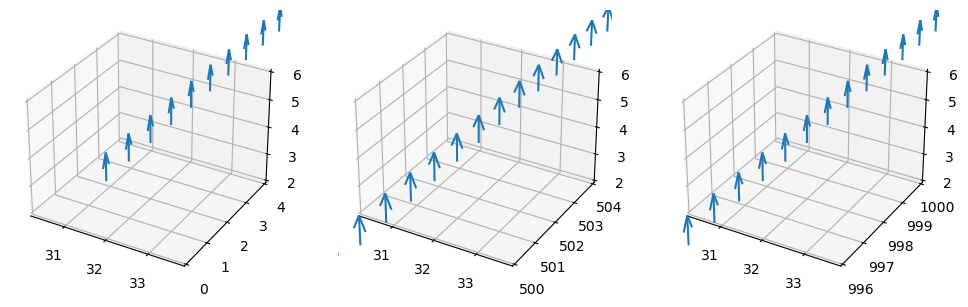

In [41]:
# Create a 3D quiver plot
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
# Plot vectors:
# length=None uses the actual lengths from U, V, W
# normalize=False preserves the relative magnitudes
ax1.quiver(X, Y, Z, U, V, W, length=1, normalize=False,arrow_length_ratio =.5)
ax2.quiver(X, Y, Z, U, V, W, length=1, normalize=False,arrow_length_ratio =.5)
step = 1
ax3.quiver(X[::step], Y[::step], Z[::step], U[::step], V[::step], W[::step], length=1, normalize=True, arrow_length_ratio =.5)

# Optionally, adjust limits to fit all vectors
ax1.set_ylim([0,4])
ax1.set_zlim([2,6])

ax2.set_ylim([500,504])
#ax2.set_ylim([990,1000])
ax2.set_zlim([2,6])

#ax1.set_ylim([,10])
#ax2.set_ylim([990,1000])
ax3.set_ylim([996,1000])
ax3.set_zlim([2,6])

#fig.suptitle('3D Vector Field')
plt.show()

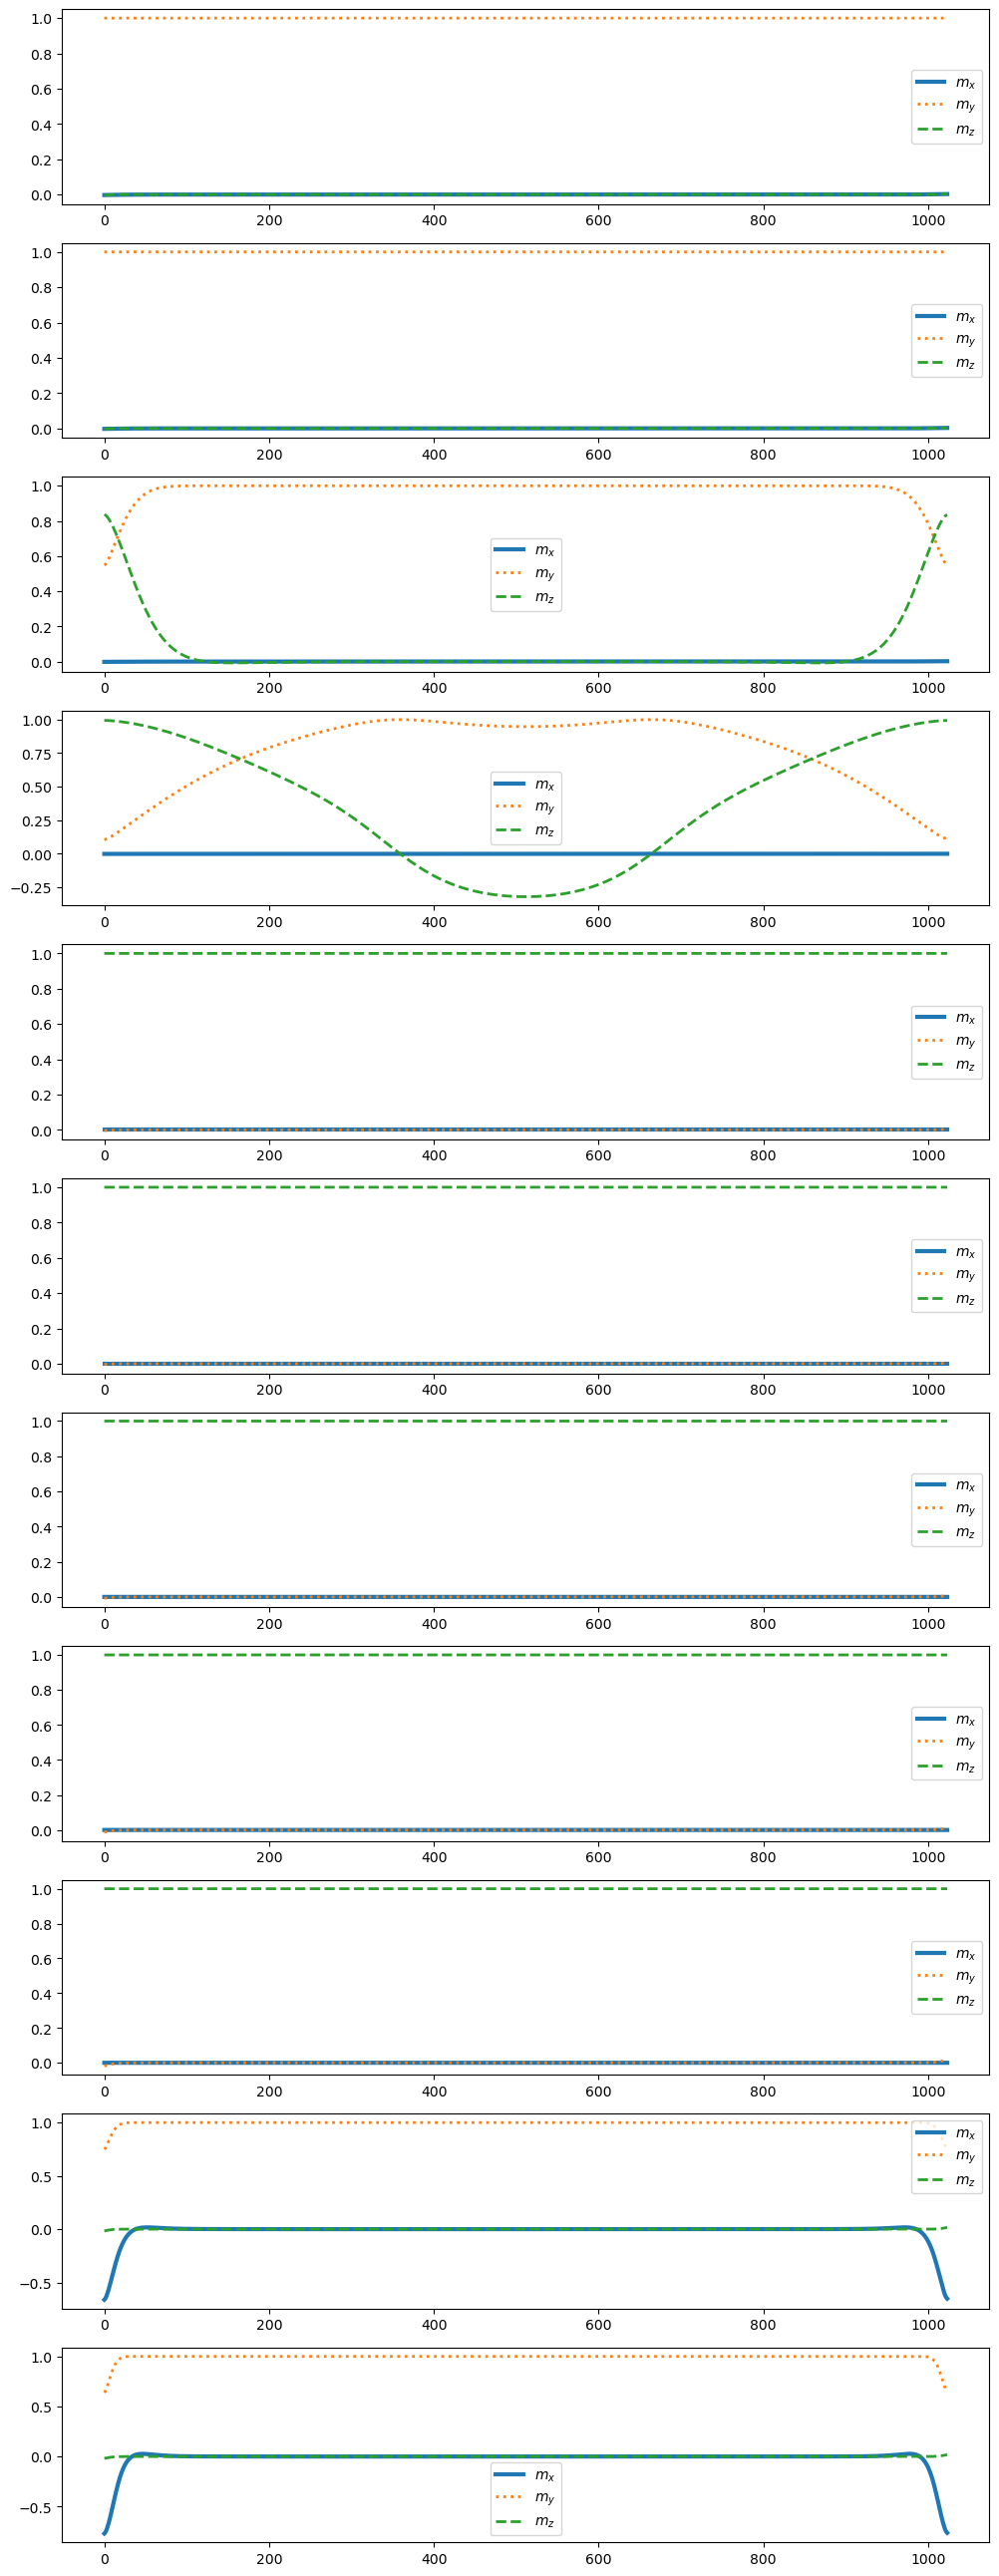

In [42]:
fig, ax = plt.subplots(len(dfs),1,figsize=(12,len(dfs)*3))

[ax[i].plot(dfs[i]['y'].values,dfs[i]['u'].values,label='$m_x$',lw=3) for i in range(len(dfs))];
[ax[i].plot(dfs[i]['y'].values,dfs[i]['v'].values,label='$m_y$',lw=2,ls=':') for i in range(len(dfs))];
[ax[i].plot(dfs[i]['y'].values,dfs[i]['w'].values,label='$m_z$',lw=2,ls='--') for i in range(len(dfs))];

[ax[i].legend() for i in range(len(dfs))];

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Ms = 300
A = 5

# 1. Load the CSV (no header; adjust path if needed)

#fname_spin = ["spin_textures/A5pJ_Ms300k_Ku1_"+str(i)+"kJ.ovf" for i in [30,35,40,45,50]] 

#fname_spin = fname_spin + ['spin_textures/A5pJ_Ms300k_Ku1_50kJ_DMI_'+str(i)+'mJ.ovf' for i in [0,10,20,30,40,50]]

fname_spin = ["spin_textures/runs/A"+str(A)+"pJ_Ms"+str(Ms)+"k_Ku1_"+str(i)+"kJ.ovf" for i in [30,32.5,35,37.5,40,42.5,45,46,47,48,49,50]]# + ["spin_textures/A"+str(A)+"pJ_Ms"+str(Ms)+"k_Ku1_5-65kJ/m0000"+str(i)+".ovf" for i in np.arange(10,13)] 

#fname_spin = ["spin_textures/runs/A"+str(A)+"pJ_Ms"+str(Ms)+"k_Ku1_"+str(i)+"kJ.ovf" for i in [10,15,20,25,30]]# + ["spin_textures/A"+str(A)+"pJ_Ms"+str(Ms)+"k_Ku1_5-65kJ/m0000"+str(i)+".ovf" for i in np.arange(10,13)] 
#fname_spin = ["spin_textures/runs/m00000"+str(i)+".ovf" for i in range(10)] + ["spin_textures/runs/m0000"+str(i)+".ovf" for i in np.arange(10,18)] 

dfs = [pd.read_csv(
    name,
    header=None,
    skiprows=28,
    skipfooter=2,
    delimiter=' ',
    index_col=False,
    names=['u', 'v', 'w']
) for name in fname_spin]

/tmp/ipykernel_693/72234567.py:19: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  dfs = [pd.read_csv(
/tmp/ipykernel_693/72234567.py:19: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  dfs = [pd.read_csv(
/tmp/ipykernel_693/72234567.py:19: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  dfs = [pd.read_csv(
/tmp/ipykernel_693/72234567.py:19: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  dfs = [pd.read_csv(
/tmp/ipykernel_693/72234567.py:19: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sk

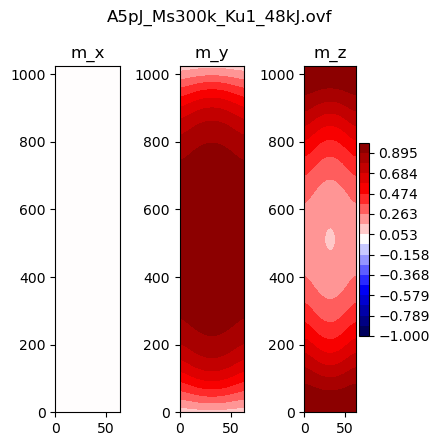

In [106]:
j=9

fig, ax = plt.subplots(1,3,figsize=(4.5,4.5),layout='tight')
im = []

texture = np.array(dfs[j]).reshape(8,1024,64,3)

[im.append(ax[i].contourf(texture[7,:,:,i],vmin=-1,vmax=1,levels=np.linspace(-1,1,20),cmap='seismic')) for i in [0,1,2]]
[ax[i].set_title(["m_x","m_y","m_z"][i]) for i in [0,1,2]];
fig.colorbar(im[2]);
fig.suptitle(fname_spin[j].split("/")[-1]);